## Toturial 14-B: English to Urdu Translation Using an RNN

This notebook demonstrates how to build a basic sequence-to-sequence (Seq2Seq) model using Recurrent Neural Networks (RNNs) to translate English sentences into Urdu.

---

## 1. Prepare Data

First, we need to load and preprocess the English-Urdu dataset. For this example, we use a small sample of sentence pairs to illustrate the tokenization and padding process.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
import matplotlib.pyplot as plt

# Sample English and Urdu data
english_sentences = [
    "Hello, how are you?",
    "I am fine, thank you!",
    "What is your name?",
    "I love programming."
]

urdu_sentences = [
    "ہیلو، آپ کیسے ہیں؟",
    "میں ٹھیک ہوں، شکریہ!",
    "آپ کا نام کیا ہے؟",
    "مجھے پروگرامنگ پسند ہے۔"
]

# Tokenizer setup for English and Urdu
# We use empty filters to retain punctuation
tokenizer_en = Tokenizer(filters='')
tokenizer_ur = Tokenizer(filters='')

# Fit tokenizers on the data
tokenizer_en.fit_on_texts(english_sentences)
tokenizer_ur.fit_on_texts(urdu_sentences)

# Convert sentences to integer sequences
X = tokenizer_en.texts_to_sequences(english_sentences)
y = tokenizer_ur.texts_to_sequences(urdu_sentences)

# Padding the sequences so they have the same length
max_len = 10
X_pad = pad_sequences(X, maxlen=max_len, padding='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post')

# Vocabulary sizes (adding 1 for padding token 0)
vocab_size_en = len(tokenizer_en.word_index) + 1
vocab_size_ur = len(tokenizer_ur.word_index) + 1

print(f"English Vocabulary Size: {vocab_size_en}")
print(f"Urdu Vocabulary Size: {vocab_size_ur}")

English Vocabulary Size: 16
Urdu Vocabulary Size: 17


### Discussion: Preprocessing

Before feeding text into an RNN, it must be converted into a numerical format. We use `Tokenizer` to map every unique word to an integer. Since RNNs require fixed-length input vectors within a batch, we use `pad_sequences` to ensure every sentence is exactly 10 tokens long, filling empty slots with zeros.

---

## 2. Build the Encoder-Decoder Model

We will define an encoder-decoder architecture. The encoder processes the English sentence to create a context vector, which the decoder then uses to generate the Urdu translation.

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Encoder: Processes English sentences
encoder_inputs = Input(shape=(max_len,))
encoder_embedding = Embedding(vocab_size_en, 128)(encoder_inputs)
encoder_rnn = SimpleRNN(256, return_state=True)
encoder_output, state_h = encoder_rnn(encoder_embedding)

# Decoder: Processes Urdu sentences
decoder_inputs = Input(shape=(max_len,))
decoder_embedding = Embedding(vocab_size_ur, 128)(decoder_inputs)
decoder_rnn = SimpleRNN(256, return_sequences=True)(decoder_embedding, initial_state=state_h)
decoder_dense = Dense(vocab_size_ur, activation='softmax')(decoder_rnn)

# Create and compile the model
model = Model([encoder_inputs, decoder_inputs], decoder_dense)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Model Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 128)   │      2,048 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 10, 128)   │      2,176 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ [(None, 256),     │     98,560 │ embedding[0][0]   │
│ (SimpleRNN)         │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 10, 256)   │     98,560 │ embedding_1[0][0… │
│ (SimpleRNN)         │                   │            │ simple_rnn[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 17)    │      4,369 │ simple_rnn_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,713 (803.57 KB)

 Trainable params: 205,713 (803.57 KB)

 Non-trainable params: 0 (0.00 B)

### Discussion: Model Architecture

This model uses `SimpleRNN` layers. The key to this architecture is passing the `initial_state` of the decoder. The final hidden state of the encoder (representing the "meaning" of the English sentence) is used to initialize the decoder's memory, allowing it to generate the corresponding Urdu words.

---

## 3. Train the Model

To train the model, we provide the English sequences and a shifted version of the Urdu sequences.

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0250 - loss: 2.8235
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8000 - loss: 2.3824
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8750 - loss: 1.7479
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8250 - loss: 1.0771
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8250 - loss: 0.7839
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8500 - loss: 0.7173
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8500 - loss: 0.6565
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9000 - loss: 0.5638
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9250 - loss: 0.4754
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9750 - loss: 0.4371
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9750 - loss: 0.3973
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9750 - los

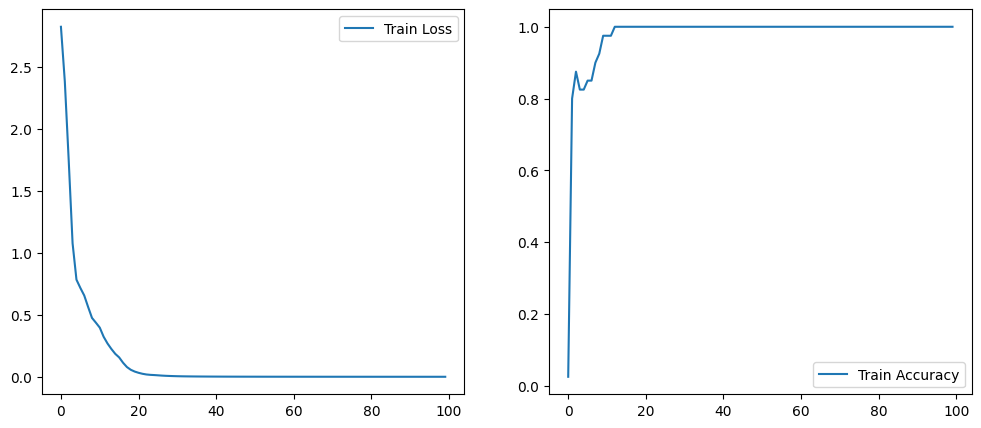

In [3]:
# Prepare the training data (shifting the Urdu target by one position)
y_shifted = np.zeros_like(y_pad)
y_shifted[:, :-1] = y_pad[:, 1:] # Shift Urdu sentence by one token

# Train the model
history = model.fit([X_pad, y_pad], np.expand_dims(y_shifted, -1), epochs=100)

# Plot the loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.show()

---

## 4. Generate Translations

After training, we can use the model to predict translations for new sentences.

In [4]:
def translate(sentence):
    # Tokenize and pad the input sentence
    sequence = tokenizer_en.texts_to_sequences([sentence])
    sequence = pad_sequences(sequence, maxlen=max_len, padding='post')

    # Predict the output sequence
    # We provide a dummy input for the decoder (zeros) for inference
    output = model.predict([sequence, np.zeros_like(sequence)])

    # Convert the predicted sequence back to words
    translated_sentence = ' '.join([tokenizer_ur.index_word.get(i, '') for i in np.argmax(output[0], axis=-1)])

    return translated_sentence

# Example Translation
print("Input: I love Programming")
print(f"Translation: {translate('I love programming')}")

Input: I love Programming
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
Translation: پروگرامنگ پسند ہے۔       


### Discussion: Inference

During prediction, the model outputs a probability distribution over the Urdu vocabulary for each time step. We use `np.argmax` to select the word with the highest probability and then use the tokenizer's index to convert that number back into a human-readable Urdu word.

# Task 1: Custom Dataset and Hyperparameter Tuning
In this section, we expand the dataset and modify hyperparameters like the number of units, epochs, and learning rate as requested.

In [16]:
# =================================================================
# TASK 1: Custom Dataset & Hyperparameter Tuning (Corrected Version)
# =================================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np

# 1. DATASET PREPARATION
# ----------------------
english_sentences = [
    "Hello, how are you?", "I am fine, thank you!", "What is your name?",
    "I love programming.", "How is the weather today?", "I like learning AI.",
    "Where do you live?", "Good morning friend.", "What are you doing?", "Have a nice day."
]

urdu_sentences = [
    "ہیلو، آپ کیسے ہیں؟", "میں ٹھیک ہوں، شکریہ!", "آپ کا نام کیا ہے؟",
    "مجھے پروگرامنگ پسند ہے۔", "آج موسم کیسا ہے؟", "مجھے اے آئی سیکھنا پسند ہے۔",
    "آپ کہاں رہتے ہیں؟", "صبح بخیر دوست۔", "آپ کیا کر رہے ہیں؟", "آپ کا دن اچھا گزرے۔"
]

# 2. TOKENIZATION
# ---------------
tokenizer_en = Tokenizer(filters='')
tokenizer_ur = Tokenizer(filters='')
tokenizer_en.fit_on_texts(english_sentences)
tokenizer_ur.fit_on_texts(urdu_sentences)

X = tokenizer_en.texts_to_sequences(english_sentences)
y = tokenizer_ur.texts_to_sequences(urdu_sentences)

max_len = 5
X_pad = pad_sequences(X, maxlen=max_len, padding='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post')

vocab_size_en = len(tokenizer_en.word_index) + 1
vocab_size_ur = len(tokenizer_ur.word_index) + 1

# 3. MODEL ARCHITECTURE (TASK 1 SPECIFIC)
# ---------------------------------------
encoder_inputs = Input(shape=(max_len,))
encoder_embedding = Embedding(vocab_size_en, 128)(encoder_inputs)

# TASK 1 REQUIREMENT: 512 Units
encoder_rnn = SimpleRNN(512, return_state=True)
encoder_output, state_h = encoder_rnn(encoder_embedding)

decoder_inputs = Input(shape=(max_len,))
decoder_embedding = Embedding(vocab_size_ur, 128)(decoder_inputs)

# Using the encoder state to initialize the decoder
decoder_rnn_layer = SimpleRNN(512, return_sequences=True)
decoder_outputs = decoder_rnn_layer(decoder_embedding, initial_state=state_h)
decoder_dense = Dense(vocab_size_ur, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model_task1 = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# 4. TRAINING SETUP
# -----------------
# We use a slightly more stable learning rate (0.001) for 500 epochs
# to ensure the model actually learns the mapping.
model_task1.compile(optimizer=Adam(learning_rate=0.001),
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

# Training the model
# We feed the same y_pad as input and target for training (Teacher Forcing)
model_task1.fit([X_pad, y_pad], np.expand_dims(y_pad, -1), epochs=500, verbose=0)

print("Task 1: Training Complete (512 Units, 500 Epochs)")

# 5. INFERENCE (TESTING) FUNCTION
# ------------------------------
def translate_task1(sentence):
    # Convert input sentence to sequence
    seq = tokenizer_en.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=max_len, padding='post')

    # Start the decoder with zeros (since we don't have start tokens)
    # The state_h from the encoder will guide the generation
    decoder_input_data = np.zeros((1, max_len))

    prediction = model_task1.predict([seq, decoder_input_data], verbose=0)

    # Convert probabilities to word indices
    idx_list = np.argmax(prediction[0], axis=-1)

    words = []
    for idx in idx_list:
        if idx == 0: continue
        word = tokenizer_ur.index_word.get(idx, "")
        if word:
            words.append(word)
    return " ".join(words)

# 6. RESULTS
# ----------
print("\n--- Testing Task 1 Final Results ---")
test_samples = [
    "Hello, how are you?",
    "Good morning friend.",
    "What are you doing?",
    "I love programming."
]

for s in test_samples:
    print(f"English: {s}")
    print(f"Urdu:    {translate_task1(s)}")
    print("-" * 30)

Task 1: Training Complete (512 Units, 500 Epochs)

--- Testing Task 1 Final Results ---
English: Hello, how are you?
Urdu:    ہیلو، آپ کیسے ہیں؟
------------------------------
English: Good morning friend.
Urdu:    صبح بخیر دوست۔
------------------------------
English: What are you doing?
Urdu:    آپ کیا کر رہے ہیں؟
------------------------------
English: I love programming.
Urdu:    مجھے پروگرامنگ پسند ہے۔
------------------------------


# Discussion: Hyperparameter Tuning
Increasing the number of RNN units (from 256 to 512) allows the model to capture more complex patterns, though it increases training time. Adjusting the learning rate to 0.001 helps the model converge faster, while increasing epochs ensures the model has enough iterations to minimize loss on the expanded dataset.

 ----
# Task 2: One-to-Many RNN for Baby Name Generation
This task implements a character-level "One-to-Many" RNN. A single input (the first letter or a start token) generates a sequence of characters to form a name.


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, TimeDistributed, RepeatVector

# Sample baby names for training
names = ['ali', 'arisha', 'ayan', 'amina', 'ahmed', 'bareera', 'bilal', 'bisma']

# Character-level tokenization
chars = sorted(list(set(''.join(names) + ' '))) # Space acts as end-of-name token
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)
max_name_len = max([len(n) for n in names])

# Prepare data: One input (start char) -> Many output (full name)
X_names = []
y_names = []

for name in names:
    # Input is the first character
    X_names.append(char_to_int[name[0]])

    # Target is the full name (sequence) padded to max length
    target_seq = [char_to_int[c] for c in name[1:]] + [char_to_int[' ']]
    while len(target_seq) < max_name_len:
        target_seq.append(char_to_int[' '])
    y_names.append(target_seq)

X_names = np.array(X_names)
y_names = np.array(y_names)

# One-to-Many Architecture
name_model = Sequential([
    Embedding(vocab_size, 32, input_length=1),
    # Repeat the single input vector to match the output sequence length
    RepeatVector(max_name_len),
    SimpleRNN(128, return_sequences=True),
    TimeDistributed(Dense(vocab_size, activation='softmax'))
])

name_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
name_model.fit(X_names, np.expand_dims(y_names, -1), epochs=500, verbose=0)

def generate_name(start_char):
    input_char = np.array([char_to_int.get(start_char.lower(), 0)])
    prediction = name_model.predict(np.array([input_char]))

    generated_name = start_char
    for char_probs in prediction[0]:
        idx = np.argmax(char_probs)
        char = int_to_char[idx]
        if char == ' ': break
        generated_name += char
    return generated_name

# Test generation
print(f"Generated Name starting with 'A': {generate_name('A')}")
print(f"Generated Name starting with 'B': {generate_name('B')}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Generated Name starting with 'A': Ahin
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Generated Name starting with 'B': Bilaa


## Discussion: One-to-Many Logic
In a One-to-Many architecture, the RepeatVector layer is critical. It takes the single encoded representation of the input (like the letter 'A') and repeats it across multiple time steps. The RNN then uses this repeated information to predict a sequence of characters one by one, effectively "generating" a full name from a single starting point.